# Uncertainty Explainer — Demo Workflow

Este notebook muestra el pipeline completo de la librería:

1. **Datos**: generamos un dataset de regresión sintético
2. **Modelo**: entrenamos un `RandomForestRegressor`
3. **Predicción conformal**: calibramos intervalos de predicción
4. **Explicación SHAP**: explicamos qué features contribuyen a la incertidumbre (ancho del intervalo)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from uncertainty_explainer.uq_explainer import UncertaintyExplanationPipeline

c:\Users\veronica.seguro\Documents\Projects\Uncertainty-Explainer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Generar datos sintéticos

In [3]:
X, y = make_regression(
    n_samples=1000,
    n_features=8,
    n_informative=5,
    noise=25.0,
    random_state=42,
)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]}, Calibracion: {X_calib.shape[0]}, Test: {X_test.shape[0]}")

Train: 600, Calibracion: 200, Test: 200


## 2. Crear el pipeline

El pipeline recibe un regresor sklearn y un metodo conformal.

Metodos conformales soportados (`conformal_method`):
- `"standard"` — conformal basico, intervalos de ancho fijo para todas las instancias
- `"normalized"` — usa `DifficultyEstimator` para adaptar el ancho segun la dificultad de cada instancia (default)
- `"mondrian"` — usa `MondrianCategorizer` para cobertura condicional por grupo
- `"normalized_mondrian"` — combina DifficultyEstimator + MondrianCategorizer

In [4]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Metodos disponibles: "standard", "normalized", "mondrian", "normalized_mondrian"
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="normalized",
)

## 3. Entrenar y calibrar

`fit()` entrena el modelo base y calibra el predictor conformal con el set de calibracion.

In [5]:
pipeline.fit(X_train, y_train, X_calib, y_calib)

## 4. Explicar la incertidumbre

`explain_uncertainty()` calcula valores SHAP sobre el ancho del intervalo conformal y genera plots automaticamente (beeswarm, bar, waterfall).

ExactExplainer explainer: 201it [03:46,  1.16s/it]                         


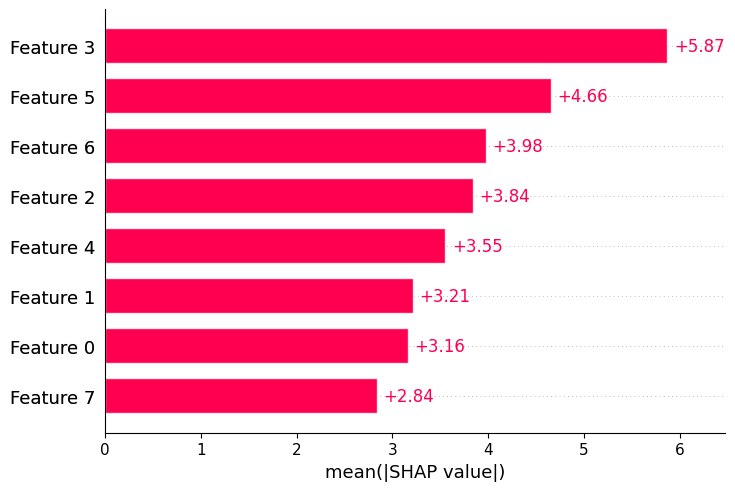

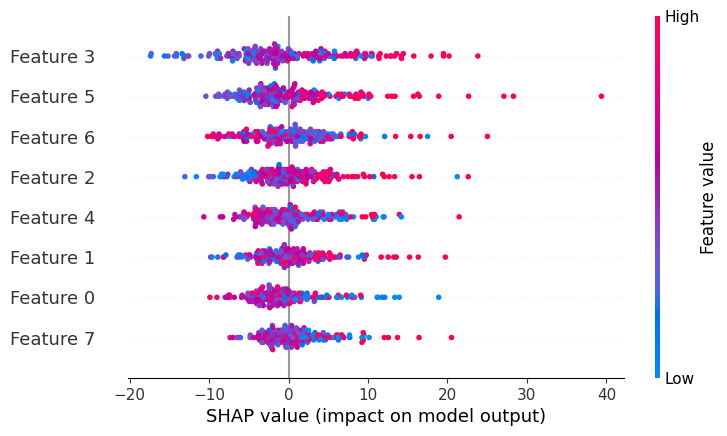

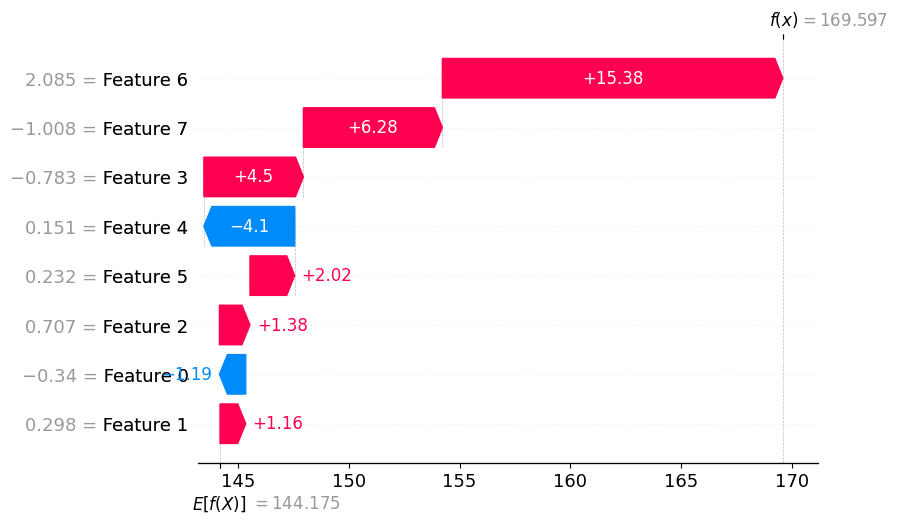

In [6]:
result = pipeline.explain_uncertainty(X_test)

## 5. Resultados

El diccionario retornado contiene los intervalos de prediccion y los valores SHAP.

In [8]:
print("Keys:", list(vars(result).keys()))
print(f"\nIntervalo promedio: {result.interval_width.mean():.2f}")
print(f"Intervalo min: {result.interval_width.min():.2f}")
print(f"Intervalo max: {result.interval_width.max():.2f}")

Keys: ['lower', 'upper', 'interval_width', 'explanation_values']

Intervalo promedio: 146.67
Intervalo min: 96.47
Intervalo max: 210.12


In [9]:
# SHAP values: cada fila es una instancia, cada columna la contribucion de un feature al ancho del intervalo
print("SHAP values shape:", result.explanation_values.values.shape)
print("\nEjemplo — contribucion de cada feature para la primera instancia de test:")
for i, val in enumerate(result.explanation_values.values[0]):
    print(f"  Feature {i}: {val:+.4f}")

SHAP values shape: (200, 8)

Ejemplo — contribucion de cada feature para la primera instancia de test:
  Feature 0: -1.1885
  Feature 1: +1.1609
  Feature 2: +1.3798
  Feature 3: +4.4963
  Feature 4: -4.1026
  Feature 5: +2.0209
  Feature 6: +15.3783
  Feature 7: +6.2772


## Explanation using Partial Dependence Plots (PDP)

In [10]:
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="normalized", 
    xai_method="pdp",
)

In [11]:
pipeline.fit(X_train, y_train, X_calib, y_calib)

c:\Users\veronica.seguro\Documents\Projects\Uncertainty-Explainer\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\veronica.seguro\Documents\Projects\Uncertainty-Explainer\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\veronica.seguro\Documents\Projects\Uncertainty-Explainer\.venv\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread

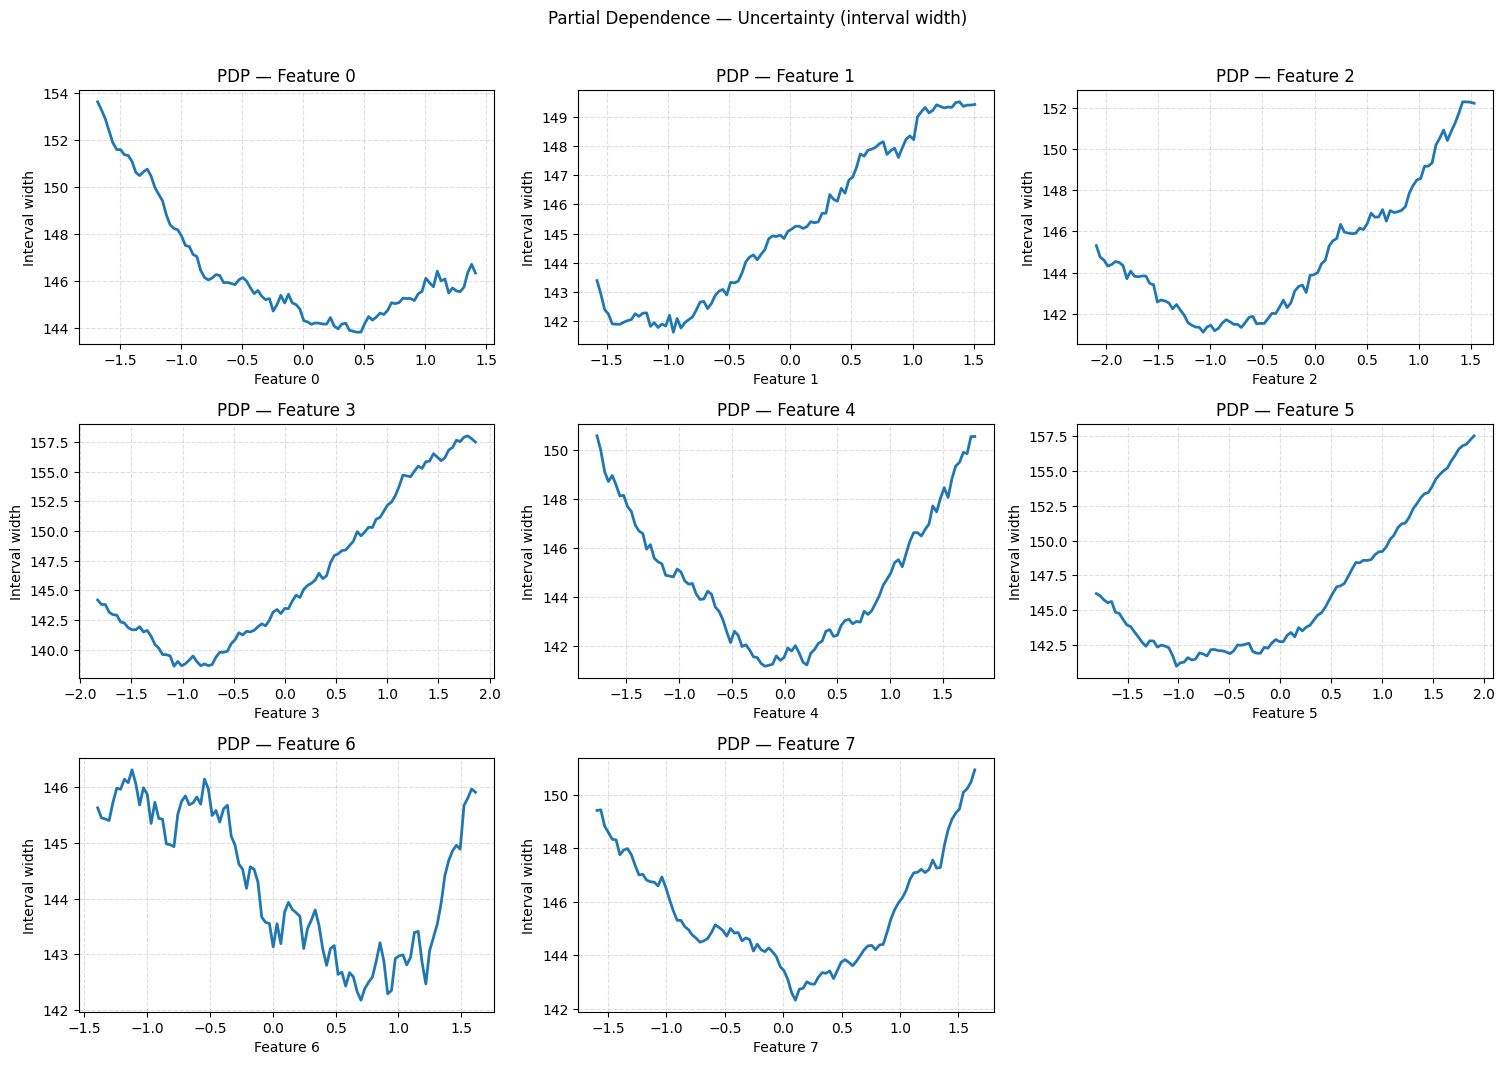

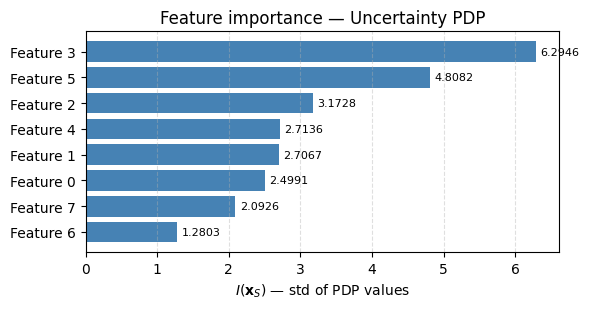

In [18]:
result = pipeline.explain_uncertainty(X_test)

In [19]:
print("Keys:", list(vars(result).keys()))
print(f"\nIntervalo promedio: {result.interval_width.mean():.2f}")
print(f"Intervalo min: {result.interval_width.min():.2f}")
print(f"Intervalo max: {result.interval_width.max():.2f}")

Keys: ['lower', 'upper', 'interval_width', 'explanation_values']

Intervalo promedio: 146.67
Intervalo min: 96.47
Intervalo max: 210.12
